In [118]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.base import clone
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

import joblib

In [119]:
df = pd.read_csv("laptops.csv")
df.head()

print(f"Dimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Dimensi dataset: 991 baris, 22 kolom


,index,brand,Model,Price,Rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,...,secondary_storage_type,secondary_storage_capacity,gpu_brand,gpu_type,is_touch_screen,display_size,resolution_width,resolution_height,OS,year_of_warranty
0,1,tecno,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,23990,63,intel,core i3,2,4,8,...,No secondary storage,0,intel,integrated,False,15.6,1920,1080,windows,1
1,2,tecno,Tecno Megabook T1 Laptop (11th Gen Core i7/ 16...,35990,67,intel,core i7,4,8,16,...,No secondary storage,0,intel,integrated,False,15.6,1920,1080,windows,1
2,3,hp,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,51100,73,amd,ryzen 5,6,12,8,...,No secondary storage,0,amd,dedicated,False,15.6,1920,1080,windows,1
3,4,acer,Acer Extensa EX214-53 Laptop (12th Gen Core i5...,39990,62,intel,core i5,12,16,8,...,No secondary storage,0,intel,integrated,False,14.0,1920,1080,windows,1
4,5,lenovo,Lenovo V15 82KDA01BIH Laptop (AMD Ryzen 3 5300...,28580,62,amd,ryzen 3,4,8,8,...,No secondary storage,0,amd,integrated,False,15.6,1920,1080,windows,1


In [120]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 991 entries, 0 to 990
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   index                       991 non-null    int64  
 1   brand                       991 non-null    str    
 2   Model                       991 non-null    str    
 3   Price                       991 non-null    int64  
 4   Rating                      991 non-null    int64  
 5   processor_brand             991 non-null    str    
 6   processor_tier              991 non-null    str    
 7   num_cores                   991 non-null    int64  
 8   num_threads                 991 non-null    int64  
 9   ram_memory                  991 non-null    int64  
 10  primary_storage_type        991 non-null    str    
 11  primary_storage_capacity    991 non-null    int64  
 12  secondary_storage_type      991 non-null    str    
 13  secondary_storage_capacity  991 non-null    in

In [121]:
print(df.isnull().sum())

index                         0
brand                         0
Model                         0
Price                         0
Rating                        0
processor_brand               0
processor_tier                0
num_cores                     0
num_threads                   0
ram_memory                    0
primary_storage_type          0
primary_storage_capacity      0
secondary_storage_type        0
secondary_storage_capacity    0
gpu_brand                     0
gpu_type                      0
is_touch_screen               0
display_size                  0
resolution_width              0
resolution_height             0
OS                            0
year_of_warranty              0
dtype: int64


In [122]:
df.drop(columns=["index", "Model"], inplace=True, errors="ignore")

In [123]:
if df["Rating"].max() > 10:
    df["Rating"] = df["Rating"] / 20

df["year_of_warranty"] = (
    df["year_of_warranty"].astype(str)
    .str.extract(r"(\d+)")[0]
    .astype(float)
)

df["is_touch_screen"] = df["is_touch_screen"].astype(int)

df["Resolution_Pixels"] = df["resolution_width"] * df["resolution_height"]
df.drop(columns=["resolution_width", "resolution_height"], inplace=True)

In [124]:
df.describe()

,Price,Rating,num_cores,num_threads,ram_memory,primary_storage_capacity,secondary_storage_capacity,is_touch_screen,display_size,year_of_warranty,Resolution_Pixels
count,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,973.000000,9.910000e+02
mean,77266.504541,3.196569,8.128153,12.191726,13.047427,610.938446,4.004036,0.088799,15.171241,1.085303,2.444286e+06
std,57384.910269,0.509529,4.215499,5.585115,5.591188,266.927666,33.553936,0.284597,0.938089,0.314138,1.073987e+06
min,9800.000000,1.200000,2.000000,0.000000,2.000000,32.000000,0.000000,0.000000,10.100000,1.000000,9.600000e+05
25%,43595.000000,2.900000,6.000000,8.000000,8.000000,512.000000,0.000000,0.000000,14.000000,1.000000,2.073600e+06
50%,61900.000000,3.200000,8.000000,12.000000,16.000000,512.000000,0.000000,0.000000,15.600000,1.000000,2.073600e+06
75%,89245.000000,3.550000,10.000000,16.000000,16.000000,512.000000,0.000000,0.000000,15.600000,1.000000,2.304000e+06
max,454490.000000,4.450000,24.000000,32.000000,36.000000,2048.000000,512.000000,1.000000,18.000000,3.000000,9.216000e+06


<Axes: xlabel='Price', ylabel='Count'>

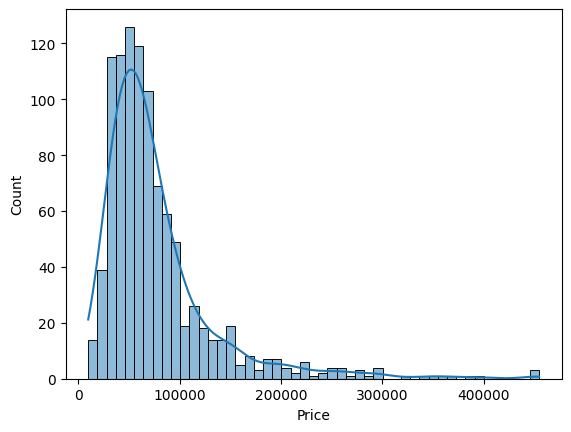

In [125]:
sns.histplot(df['Price'], kde=True)

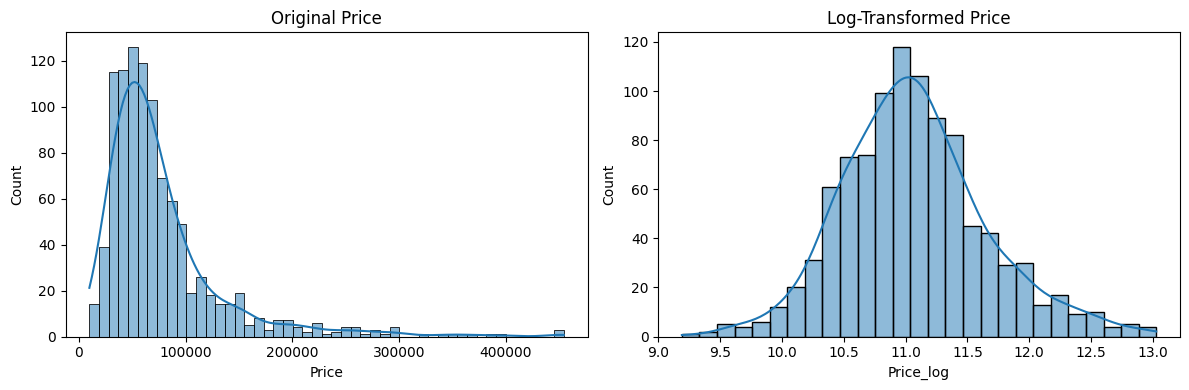

In [126]:
df['Price_log'] = np.log1p(df['Price'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Price'], kde=True, ax=axes[0])
axes[0].set_title('Original Price')

sns.histplot(df['Price_log'], kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Price')

plt.tight_layout()
plt.show()

<Axes: xlabel='Price_log'>

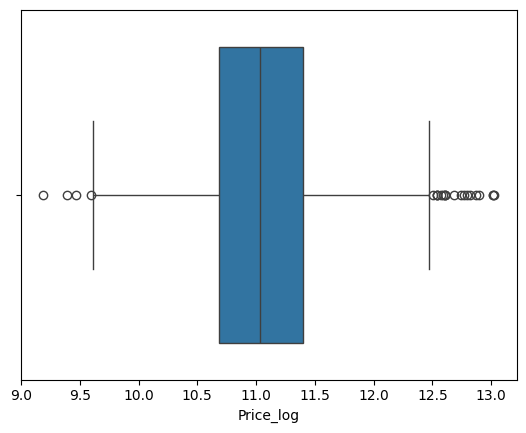

In [127]:
sns.boxplot(x=df['Price_log'])

In [128]:
target_col = "Price"
y = np.log1p(df[target_col])
X_raw = df.drop(columns=[target_col, "Price_log"])
 
X_temp, X_holdout, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

In [129]:
num_cols = [
    "Rating", "num_cores", "num_threads", "ram_memory",
    "primary_storage_capacity", "secondary_storage_capacity",
    "display_size", "Resolution_Pixels", "year_of_warranty",
    "is_touch_screen"
]

imputer = SimpleImputer(strategy="median")
X_temp[num_cols]    = imputer.fit_transform(X_temp[num_cols])
X_holdout[num_cols] = imputer.transform(X_holdout[num_cols])

cat_cols = [
    "brand", "processor_brand", "processor_tier",
    "primary_storage_type", "secondary_storage_type",
    "gpu_brand", "gpu_type", "OS"
]
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_temp[col] = le.fit_transform(X_temp[col].astype(str))

    X_holdout[col] = X_holdout[col].astype(str).map(
        lambda x, le=le: le.transform([x])[0] if x in le.classes_ else -1
    )
    encoders[col] = le

In [130]:
for col in cat_cols:
    print(col, ":", df[col].unique())

brand : <ArrowStringArray>
[    'tecno',        'hp',      'acer',    'lenovo',     'apple',   'infinix',
      'asus',      'dell',   'samsung',       'msi',     'wings',   'ultimus',
 'primebook',     'iball', 'zebronics',     'chuwi',  'gigabyte',       'jio',
     'honor',    'realme',     'avita', 'microsoft',   'fujitsu',        'lg',
    'walker',       'axl']
Length: 26, dtype: str
processor_brand : <ArrowStringArray>
['intel', 'amd', 'apple', 'other']
Length: 4, dtype: str
processor_tier : <ArrowStringArray>
[     'core i3',      'core i7',      'ryzen 5',      'core i5',
      'ryzen 3',           'm1',      'core i9',      'ryzen 7',
        'other',           'm3',           'm2',      'ryzen 9',
      'celeron', 'core ultra 7',      'pentium']
Length: 15, dtype: str
primary_storage_type : <ArrowStringArray>
['SSD', 'HDD']
Length: 2, dtype: str
secondary_storage_type : <ArrowStringArray>
['No secondary storage', 'SSD']
Length: 2, dtype: str
gpu_brand : <ArrowStringArray>
['

In [131]:
df.describe()

,Price,Rating,num_cores,num_threads,ram_memory,primary_storage_capacity,secondary_storage_capacity,is_touch_screen,display_size,year_of_warranty,Resolution_Pixels,Price_log
count,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,973.000000,9.910000e+02,991.000000
mean,77266.504541,3.196569,8.128153,12.191726,13.047427,610.938446,4.004036,0.088799,15.171241,1.085303,2.444286e+06,11.066098
std,57384.910269,0.509529,4.215499,5.585115,5.591188,266.927666,33.553936,0.284597,0.938089,0.314138,1.073987e+06,0.589099
min,9800.000000,1.200000,2.000000,0.000000,2.000000,32.000000,0.000000,0.000000,10.100000,1.000000,9.600000e+05,9.190240
25%,43595.000000,2.900000,6.000000,8.000000,8.000000,512.000000,0.000000,0.000000,14.000000,1.000000,2.073600e+06,10.682718
50%,61900.000000,3.200000,8.000000,12.000000,16.000000,512.000000,0.000000,0.000000,15.600000,1.000000,2.073600e+06,11.033292
75%,89245.000000,3.550000,10.000000,16.000000,16.000000,512.000000,0.000000,0.000000,15.600000,1.000000,2.304000e+06,11.399148
max,454490.000000,4.450000,24.000000,32.000000,36.000000,2048.000000,512.000000,1.000000,18.000000,3.000000,9.216000e+06,13.026933


In [132]:
def add_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df_fe = df_in.copy()
 
    df_fe["RAM_Storage"] = df_in["ram_memory"] * df_in["primary_storage_capacity"]
 
    df_fe["Core_Thread_Index"] = df_in["num_cores"] * df_in["num_threads"]
 
    df_fe["RAM_Per_Core"] = df_in["ram_memory"] / (df_in["num_cores"] + 1)
 
    df_fe["Warranty_RAM"] = df_in["year_of_warranty"] * df_in["ram_memory"]
 
    df_fe["Performance_Index"] = (
        df_in["ram_memory"] * df_in["num_cores"] * df_in["primary_storage_capacity"]
    )
 
    df_fe["Pixel_Density"] = df_in["Resolution_Pixels"] / (df_in["display_size"] + 1)
 
    return df_fe

In [133]:
Xb_train = X_temp.copy()
Xb_test  = X_holdout.copy()

X_train = add_features(X_temp)
X_test  = add_features(X_holdout)

In [134]:
base_models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbosity=0)
}

In [135]:
base_stacking = StackingRegressor(
    estimators=[
        ("rf",  clone(base_models["RandomForest"])),
        ("et",  clone(base_models["ExtraTrees"])),
        ("xgb", clone(base_models["XGBoost"])),
    ],
    final_estimator=LinearRegression(),
)
base_models["Stacking"] = base_stacking

In [136]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [137]:
def evaluate_models(X_tr, X_te, y_tr, y_te, label: str) -> pd.DataFrame:
    results = []
    print(f"\n{'='*80}")
    print(label)
    print(f"{'='*80}")
 
    for name, model_template in base_models.items():
        model = clone(model_template)
 
        cv_scores = cross_val_score(model, X_tr, y_tr, cv=kf, scoring="r2")
 
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
 
        r2   = r2_score(y_te, preds)
        mae  = mean_absolute_error(y_te, preds)
        rmse = np.sqrt(mean_squared_error(y_te, preds))
 
        results.append({
            "Dataset":    label,
            "Model":      name,
            "R2":         round(r2, 4),
            "MAE":        round(mae, 2),
            "RMSE":       round(rmse, 2),
            "CV_R2_Mean": round(cv_scores.mean(), 4),
            "CV_R2_Std":  round(cv_scores.std(),  4),
        })
 
        print(
            f"{name:20}"
            f"  R²={r2:.4f}"
            f"  MAE={mae:.2f}"
            f"  RMSE={rmse:.2f}"
            f"  CV_R²={cv_scores.mean():.4f} ± {cv_scores.std():.4f}"
        )
 
    return pd.DataFrame(results)

In [138]:
baseline_results = evaluate_models(Xb_train, Xb_test, y_train, y_test, "Without Feature Engineering")
 
feature_results  = evaluate_models(X_train,  X_test,  y_train, y_test, "With Feature Engineering")


Without Feature Engineering
RandomForest          R²=0.9202  MAE=0.13  RMSE=0.18  CV_R²=0.8872 ± 0.0198
GradientBoosting      R²=0.9303  MAE=0.12  RMSE=0.16  CV_R²=0.9078 ± 0.0156
ExtraTrees            R²=0.9225  MAE=0.13  RMSE=0.17  CV_R²=0.8938 ± 0.0147
XGBoost               R²=0.9183  MAE=0.13  RMSE=0.18  CV_R²=0.9004 ± 0.0168
Stacking              R²=0.9259  MAE=0.13  RMSE=0.17  CV_R²=0.9044 ± 0.0124

With Feature Engineering
RandomForest          R²=0.9085  MAE=0.14  RMSE=0.19  CV_R²=0.8850 ± 0.0127
GradientBoosting      R²=0.9189  MAE=0.13  RMSE=0.18  CV_R²=0.9111 ± 0.0116
ExtraTrees            R²=0.9157  MAE=0.13  RMSE=0.18  CV_R²=0.8939 ± 0.0180
XGBoost               R²=0.9199  MAE=0.13  RMSE=0.18  CV_R²=0.9018 ± 0.0109
Stacking              R²=0.9226  MAE=0.13  RMSE=0.17  CV_R²=0.9043 ± 0.0112


In [139]:
results = (
    pd.concat([baseline_results, feature_results])
    .sort_values(by="R2", ascending=False)
    .reset_index(drop=True)
)
 
print("\n")
print("=" * 80)
print("TOP 10 RESULTS")
print("=" * 80)
print(results.head(10).to_string(index=False))
 
print("\nBEST MODEL")
print(results.iloc[0])



TOP 10 RESULTS
                    Dataset            Model     R2  MAE  RMSE  CV_R2_Mean  CV_R2_Std
Without Feature Engineering GradientBoosting 0.9303 0.12  0.16      0.9078     0.0156
Without Feature Engineering         Stacking 0.9259 0.13  0.17      0.9044     0.0124
   With Feature Engineering         Stacking 0.9226 0.13  0.17      0.9043     0.0112
Without Feature Engineering       ExtraTrees 0.9225 0.13  0.17      0.8938     0.0147
Without Feature Engineering     RandomForest 0.9202 0.13  0.18      0.8872     0.0198
   With Feature Engineering          XGBoost 0.9199 0.13  0.18      0.9018     0.0109
   With Feature Engineering GradientBoosting 0.9189 0.13  0.18      0.9111     0.0116
Without Feature Engineering          XGBoost 0.9183 0.13  0.18      0.9004     0.0168
   With Feature Engineering       ExtraTrees 0.9157 0.13  0.18      0.8939     0.0180
   With Feature Engineering     RandomForest 0.9085 0.14  0.19      0.8850     0.0127

BEST MODEL
Dataset       Without Fea

In [140]:
best_model_name = results.iloc[0]["Model"]
best_dataset    = results.iloc[0]["Dataset"]

use_fe  = best_dataset == "With Feature Engineering"
X_final = X_train if use_fe else Xb_train

final_model = clone(base_models[best_model_name])
final_model.fit(X_final, y_train)

feature_cols = X_final.columns.tolist()

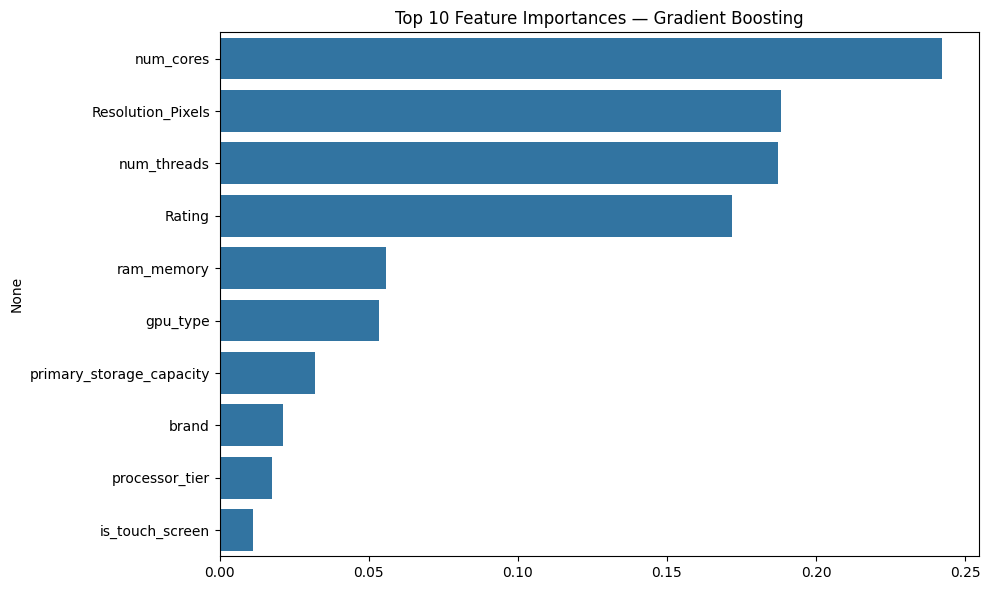

In [141]:
feat_imp = pd.Series(
    final_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values[:10], y=feat_imp.index[:10])
plt.title("Top 10 Feature Importances — Gradient Boosting")
plt.tight_layout()
plt.show()

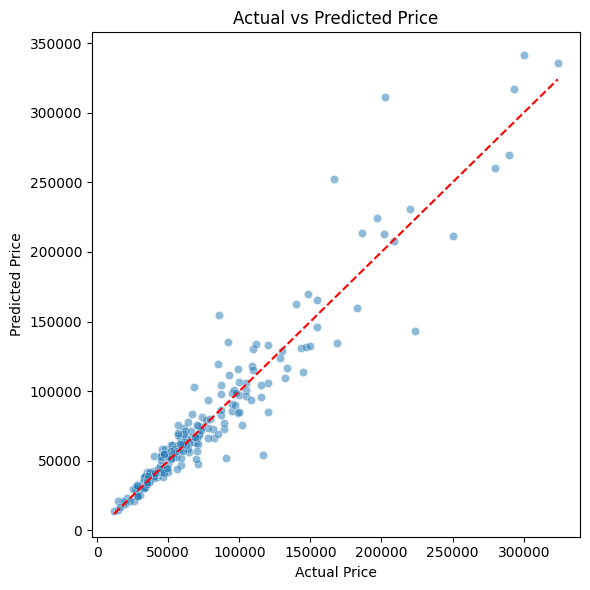

In [142]:
X_eval = X_test if use_fe else Xb_test

preds_log = final_model.predict(X_eval)
preds_actual = np.expm1(preds_log)
actual_actual = np.expm1(y_test)

plt.figure(figsize=(6, 6))
sns.scatterplot(x=actual_actual, y=preds_actual, alpha=0.5)
plt.plot([actual_actual.min(), actual_actual.max()],
         [actual_actual.min(), actual_actual.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.tight_layout()
plt.show()

In [143]:
joblib.dump(final_model, "model.pkl")
joblib.dump(imputer, "imputer.pkl")
joblib.dump(encoders, "encoders.pkl")
joblib.dump(num_cols, "num_cols.pkl")
joblib.dump(cat_cols, "cat_cols.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")

['feature_cols.pkl']

In [144]:
import time

X_sample = X_eval.iloc[:1]

start = time.time()
_ = final_model.predict(X_sample)
end = time.time()

latency_ms = (end - start) * 1000
print(f"Inference latency: {latency_ms:.2f} ms")

Inference latency: 3.79 ms
